# Prédiction du risque de crise cardiaque — dataset NHANES

Ce notebook déroule toute la démarche sur le fichier `patients_machine_learning_NHANES_avec_conclusion.csv`
(1 000 patients, 16 variables + la cible **Risque_de_crise_cardiaque** : Oui / Non) :

1. Chargement et exploration
2. Valeurs manquantes et contrôles de qualité
3. Enrichissement et indicateurs (flags)
4. Transformation et normalisation
5. Augmentation des données (SMOTE) — testée
6. Réduction de dimension (PCA) — testée
7. Comparaison de modèles, optimisation, évaluation finale
8. Interprétation du modèle retenu

Le prétraitement s'appuie sur `heart_model/pipeline.py`, **le même module que celui utilisé par le site web** :
ce qui est validé ici est exactement ce qui tourne en production.


In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

from sklearn.model_selection import train_test_split, RepeatedStratifiedKFold, cross_validate, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
                             average_precision_score, brier_score_loss, confusion_matrix, ConfusionMatrixDisplay,
                             RocCurveDisplay, PrecisionRecallDisplay, classification_report)
from sklearn.calibration import CalibrationDisplay
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

from heart_model.pipeline import (charger_donnees, preparer, build_preprocessing_steps, RENOMMAGE,
                                  COLONNES_NUMERIQUES, COLONNES_BINAIRES, COLONNES_FLAGS, RANDOM_STATE)

sns.set_style("whitegrid"); plt.rcParams["figure.figsize"] = (8, 4.5)
pd.set_option("display.max_columns", None); pd.set_option("display.width", 200)

## 1. Chargement et exploration

In [2]:
# Le CSV utilise ';' comme séparateur et ',' comme décimale, avec des espaces parasites autour des valeurs
# -> charger_donnees() gère tout cela, renomme les colonnes et encode la cible (Oui = 1, Non = 0).
X, y = charger_donnees("data/nhanes_risque_cardiaque.csv")
print("Dimensions :", X.shape, "| cible :", y.shape)
X.head()

Dimensions : (1000, 16) | cible : (1000,)


,age,sexe,type_douleur,ta_systolique,ta_diastolique,ldl,glycemie,ecg_repos,poids,taille,acide_urique,tabagisme,sedentarite,freq_cardiaque,angine_effort,sous_decalage_st
0,68,Homme,Typique angineuse,164,68,89.5,127.0,Normal,73.7,169.0,7.0,Non,Active,79,Oui,Non
1,58,Homme,Typique angineuse,146,102,60.8,88.2,Normal,73.7,168.6,5.9,Oui,S�dentaire,73,Oui,Oui
2,44,Femme,Atypique,135,74,181.2,122.8,Normal,59.3,168.7,5.8,Non,S�dentaire,83,Oui,Non
3,72,Homme,Typique angineuse,104,102,88.0,78.0,Normal,66.1,176.6,7.5,Non,Active,72,Oui,Non
4,37,Femme,Typique angineuse,134,67,101.6,117.8,Anomalie ST-T,63.1,155.5,5.9,Non,Active,69,Oui,Non


In [3]:
# Répartition de la cible : 69 % de patients à risque -> jeu de données déséquilibré (classe 'Non' minoritaire)
print(y.value_counts().rename({1: "Risque (Oui)", 0: "Pas de risque (Non)"}))
print(f"Prévalence : {y.mean():.1%}")

Risque_de_crise_cardiaque
Risque (Oui)           690
Pas de risque (Non)    310
Name: count, dtype: int64
Prévalence : 69.0%


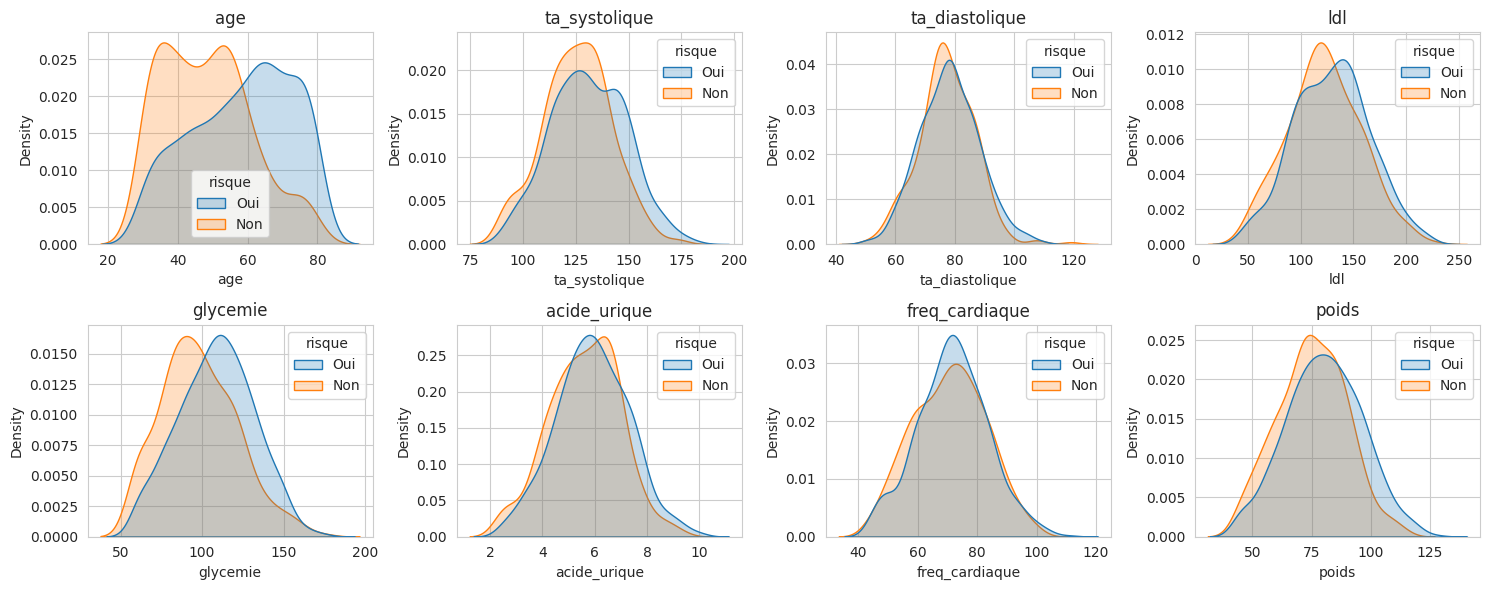

In [4]:
# Variables numériques : distributions selon la cible
num_brutes = ["age", "ta_systolique", "ta_diastolique", "ldl", "glycemie", "acide_urique", "freq_cardiaque", "poids"]
fig, axes = plt.subplots(2, 4, figsize=(15, 6))
for ax, col in zip(axes.ravel(), num_brutes):
    sns.kdeplot(data=X.assign(risque=y.map({1: "Oui", 0: "Non"})), x=col, hue="risque", fill=True, common_norm=False, ax=ax)
    ax.set_title(col)
plt.tight_layout(); plt.show()

In [5]:
# Variables catégorielles : taux de risque par modalité
cats = ["type_douleur", "ecg_repos", "sexe", "tabagisme", "sedentarite", "angine_effort", "sous_decalage_st"]
for c in cats:
    print(pd.crosstab(X[c], y, normalize="index").rename(columns={0: "Non", 1: "Oui"}).round(3), "\n")

Risque_de_crise_cardiaque    Non    Oui
type_douleur                           
Asymptomatique             0.576  0.424
Atypique                   0.135  0.865
Non angineuse              0.492  0.508
Typique angineuse          0.014  0.986 

Risque_de_crise_cardiaque     Non    Oui
ecg_repos                               
Anomalie ST-T               0.229  0.771
Hypertrophie ventriculaire  0.181  0.819
Normal                      0.344  0.656 

Risque_de_crise_cardiaque    Non    Oui
sexe                                   
Femme                      0.325  0.675
Homme                      0.296  0.704 

Risque_de_crise_cardiaque    Non    Oui
tabagisme                              
Non                        0.356  0.644
Oui                        0.209  0.791 

Risque_de_crise_cardiaque    Non    Oui
sedentarite                            
Active                     0.361  0.639
S�dentaire                 0.248  0.752 

Risque_de_crise_cardiaque    Non    Oui
angine_effort            

## 2. Valeurs manquantes et contrôles de qualité

In [6]:
# Valeurs manquantes (aucune dans ce fichier, mais le pipeline de production inclut quand même une imputation
# par la médiane / le mode, pour rester robuste face à un futur jeu de données incomplet)
print("Valeurs manquantes :", int(X.isna().sum().sum()))
print("Lignes dupliquées  :", int(X.duplicated().sum()))
# La modalité 'Sédentaire' contient un caractère accentué corrompu dans le CSV source :
print("Modalités de sedentarite :", X["sedentarite"].unique().tolist())
# -> preparer() teste donc la sous-chaîne 'dentaire' plutôt que le mot exact.

Valeurs manquantes : 0
Lignes dupliquées  : 0
Modalités de sedentarite : ['Active', 'S�dentaire']


In [7]:
# Cohérence : l'IMC fourni correspond-il à poids / taille² ?
brut = pd.read_csv("data/nhanes_risque_cardiaque.csv", sep=";", decimal=",", skipinitialspace=True)
brut.columns = [c.strip() for c in brut.columns]
ecart = (brut["Poids_kg"] / (brut["Taille_cm"] / 100) ** 2 - brut["IMC_kg_m2"]).abs().max()
print(f"Écart maximal IMC fourni vs recalculé : {ecart:.3f} (simple arrondi)")
# -> l'IMC est donc 100 % redondant avec poids et taille : on le RECALCULE (le site web ne demande que poids + taille).
# Détection de valeurs aberrantes (IQR) sur les variables continues
for c in ["ta_systolique", "ta_diastolique", "ldl", "glycemie", "acide_urique", "freq_cardiaque"]:
    q1, q3 = X[c].quantile([.25, .75]); i = q3 - q1
    n = int(((X[c] < q1 - 1.5 * i) | (X[c] > q3 + 1.5 * i)).sum())
    print(f"{c:16s} : {n} valeurs hors IQR (conservées : elles restent physiologiquement plausibles)")

Écart maximal IMC fourni vs recalculé : 0.050 (simple arrondi)
ta_systolique    : 1 valeurs hors IQR (conservées : elles restent physiologiquement plausibles)
ta_diastolique   : 5 valeurs hors IQR (conservées : elles restent physiologiquement plausibles)
ldl              : 0 valeurs hors IQR (conservées : elles restent physiologiquement plausibles)
glycemie         : 2 valeurs hors IQR (conservées : elles restent physiologiquement plausibles)
acide_urique     : 3 valeurs hors IQR (conservées : elles restent physiologiquement plausibles)
freq_cardiaque   : 4 valeurs hors IQR (conservées : elles restent physiologiquement plausibles)


## 3. Enrichissement et indicateurs (flags)

`preparer()` ajoute : **IMC** (poids/taille²), **pression pulsée** (systolique − diastolique), **pression artérielle moyenne**,
des **flags cliniques** (hypertension ≥ 140/90, LDL ≥ 160, glycémie ≥ 126, obésité IMC ≥ 30, acide urique élevé selon le sexe,
fréquence cardiaque anormale, âge ≥ 60) et un **score de risque cumulatif**.

In [8]:
E = preparer(X)
nouvelles = ["imc", "pression_pulsee", "pam", "score_risque"] + COLONNES_FLAGS
print(E[nouvelles].describe().T[["mean", "min", "max"]].round(2))
print("\nPrévalence des flags et taux de risque associé :")
tab = pd.DataFrame({f: [E[f].mean(), y[E[f] == 1].mean() if E[f].sum() else np.nan, y[E[f] == 0].mean()] for f in COLONNES_FLAGS},
                   index=["part des patients", "risque si flag = 1", "risque si flag = 0"]).T
tab.round(3)

                          mean    min     max
imc                      27.27  12.70   49.08
pression_pulsee          51.44  -7.00  120.00
pam                      94.98  68.67  122.00
score_risque              2.55   0.00    8.00
flag_hypertension         0.37   0.00    1.00
flag_ldl_eleve            0.18   0.00    1.00
flag_hyperglycemie        0.20   0.00    1.00
flag_obesite              0.32   0.00    1.00
flag_acide_urique_eleve   0.31   0.00    1.00
flag_freq_anormale        0.05   0.00    1.00
flag_senior               0.41   0.00    1.00

Prévalence des flags et taux de risque associé :


,part des patients,risque si flag = 1,risque si flag = 0
flag_hypertension,0.372,0.801,0.624
flag_ldl_eleve,0.177,0.763,0.674
flag_hyperglycemie,0.197,0.817,0.659
flag_obesite,0.319,0.812,0.633
flag_acide_urique_eleve,0.311,0.736,0.669
flag_freq_anormale,0.047,0.766,0.686
flag_senior,0.413,0.862,0.569


## 4. Transformation et normalisation

Les variables numériques sont **imputées (médiane) puis standardisées** ; les catégories (`type_douleur`, `ecg_repos`) sont
**encodées en one-hot** ; les binaires et les flags passent tels quels. Tout est appris **uniquement sur le train** (dans le pipeline).

In [9]:
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)
prepro = Pipeline(build_preprocessing_steps(use_pca=False)).fit(X_tr)
Xt = prepro.transform(X_tr)
noms = prepro.named_steps["transformation"].get_feature_names_out()
print("Train :", X_tr.shape, "-> matrice transformée :", Xt.shape, "| Test :", X_te.shape)
print("Variables numériques standardisées (moyenne ≈ 0, écart-type ≈ 1) :")
print(pd.DataFrame(Xt[:, :len(COLONNES_NUMERIQUES)], columns=COLONNES_NUMERIQUES).agg(["mean", "std"]).round(2))

Train : (800, 16) -> matrice transformée : (800, 27) | Test : (200, 16)
Variables numériques standardisées (moyenne ≈ 0, écart-type ≈ 1) :
      age  ta_systolique  ta_diastolique  ldl  glycemie  imc  acide_urique  freq_cardiaque
mean  0.0            0.0             0.0  0.0       0.0  0.0          -0.0             0.0
std   1.0            1.0             1.0  1.0       1.0  1.0           1.0             1.0


## 5. Augmentation des données (SMOTE)

SMOTE crée des patients synthétiques de la classe minoritaire (« Non »). Il est appliqué **uniquement pendant l'entraînement,
à l'intérieur de chaque pli de validation croisée** (pipeline `imblearn`), pour ne jamais contaminer la validation.
On mesure s'il apporte un gain réel.

In [10]:
cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=2, random_state=RANDOM_STATE)
scoring = ["accuracy", "precision", "recall", "f1", "roc_auc", "average_precision", "balanced_accuracy"]

def evaluer(modele, smote=False, pca=False):
    etapes = build_preprocessing_steps(use_pca=pca, n_composantes=0.95 if pca else None)
    if smote: etapes.append(("smote", SMOTE(random_state=RANDOM_STATE)))
    etapes.append(("modele", modele))
    s = cross_validate(ImbPipeline(etapes), X_tr, y_tr, cv=cv, scoring=scoring, n_jobs=-1)
    return {k: np.mean(s["test_" + k]) for k in scoring}

res = {}
for nom, mod in {"Régression logistique": LogisticRegression(max_iter=2000), "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)}.items():
    res[(nom, "sans SMOTE")] = evaluer(mod)
    res[(nom, "avec SMOTE")] = evaluer(mod, smote=True)
pd.DataFrame(res).T.round(3)

accuracy  precision  recall     f1  roc_auc  average_precision  balanced_accuracy
Régression logistique sans SMOTE     0.924      0.940   0.951  0.945    0.983              0.993              0.908
                      avec SMOTE     0.929      0.966   0.930  0.948    0.983              0.993              0.929
Random Forest         sans SMOTE     0.883      0.892   0.946  0.918    0.951              0.977              0.845
                      avec SMOTE     0.885      0.909   0.928  0.918    0.953              0.978              0.859

In [11]:
# Lecture : SMOTE redistribue précision et rappel (balanced_accuracy ↑, rappel ↓) mais ne change presque pas le ROC-AUC.
# Il déforme aussi les probabilités (classes artificiellement équilibrées) alors que le site affiche une probabilité.
# Décision : on N'UTILISE PAS SMOTE dans le modèle final ; le déséquilibre (69/31) est modéré.

## 6. Réduction de dimension (PCA)

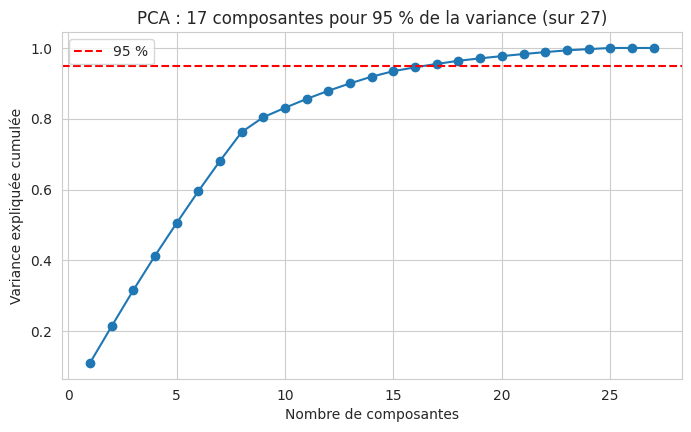

accuracy  precision  recall     f1  roc_auc  average_precision  balanced_accuracy
Régression logistique sans PCA     0.924      0.940   0.951  0.945    0.983              0.993              0.908
                      PCA 95 %     0.921      0.936   0.950  0.943    0.980              0.992              0.903

In [12]:
from sklearn.decomposition import PCA
Xt_all = prepro.transform(X_tr)
pca = PCA().fit(Xt_all)
cum = np.cumsum(pca.explained_variance_ratio_)
n95 = int(np.argmax(cum >= 0.95) + 1)
plt.plot(range(1, len(cum) + 1), cum, marker="o"); plt.axhline(.95, color="red", ls="--", label="95 %")
plt.xlabel("Nombre de composantes"); plt.ylabel("Variance expliquée cumulée"); plt.title(f"PCA : {n95} composantes pour 95 % de la variance (sur {Xt_all.shape[1]})")
plt.legend(); plt.show()
res_pca = {("Régression logistique", "sans PCA"): evaluer(LogisticRegression(max_iter=2000)),
           ("Régression logistique", "PCA 95 %"): evaluer(LogisticRegression(max_iter=2000), pca=True)}
pd.DataFrame(res_pca).T.round(3)

In [13]:
# Lecture : la PCA ne gagne rien (légère perte) et rend le modèle ininterprétable (composantes = mélanges de variables).
# Décision : PAS de PCA dans le modèle final -> on peut expliquer chaque prédiction variable par variable.

## 7. Comparaison de modèles

In [14]:
modeles = {
    "Régression logistique": LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE),
    "SVM (RBF)": SVC(probability=True, random_state=RANDOM_STATE),
    "KNN": KNeighborsClassifier(15),
    "Naive Bayes": GaussianNB(),
}
comp = pd.DataFrame({n: evaluer(m) for n, m in modeles.items()}).T.sort_values("roc_auc", ascending=False)
comp.round(3)

,accuracy,precision,recall,f1,roc_auc,average_precision,balanced_accuracy
Régression logistique,0.924,0.940,0.951,0.945,0.983,0.993,0.908
XGBoost,0.911,0.926,0.947,0.936,0.973,0.988,0.888
Gradient Boosting,0.912,0.926,0.948,0.937,0.972,0.987,0.889
SVM (RBF),0.897,0.906,0.949,0.927,0.966,0.985,0.865
Random Forest,0.883,0.892,0.946,0.918,0.951,0.977,0.845
Naive Bayes,0.801,0.935,0.766,0.841,0.926,0.960,0.823
KNN,0.837,0.871,0.897,0.883,0.896,0.939,0.800


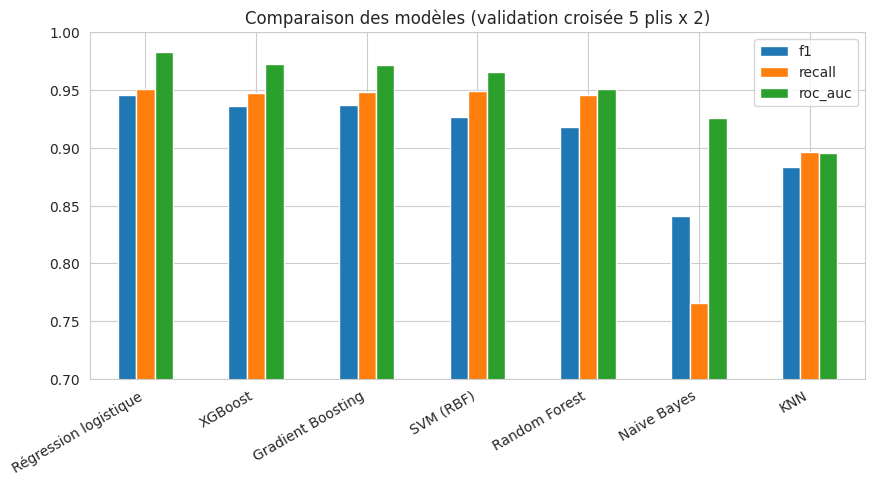

In [15]:
comp[["f1", "recall", "roc_auc"]].plot(kind="bar", figsize=(10, 4.5)); plt.ylim(.7, 1); plt.xticks(rotation=30, ha="right")
plt.title("Comparaison des modèles (validation croisée 5 plis x 2)"); plt.show()

### Optimisation du modèle retenu
La **régression logistique** arrive en tête (ROC-AUC) tout en étant **interprétable** : on règle sa régularisation `C`.

In [16]:
grille = GridSearchCV(Pipeline([("prepro", Pipeline(build_preprocessing_steps())), ("modele", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))]),
                      {"modele__C": [0.01, 0.03, 0.1, 0.3, 1, 3, 10, 30]}, scoring="roc_auc", cv=cv, n_jobs=-1).fit(X_tr, y_tr)
print("Meilleur C :", grille.best_params_["modele__C"], "| ROC-AUC (CV) :", round(grille.best_score_, 4))
final = grille.best_estimator_

Meilleur C : 3 | ROC-AUC (CV) : 0.984


## 8. Évaluation finale sur le jeu de test (jamais utilisé avant)

                     precision    recall  f1-score   support

Pas de risque (Non)       0.91      0.97      0.94        62
       Risque (Oui)       0.99      0.96      0.97       138

           accuracy                           0.96       200
          macro avg       0.95      0.96      0.95       200
       weighted avg       0.96      0.96      0.96       200

ROC-AUC 0.9891 | PR-AUC 0.9949 | Brier 0.0388


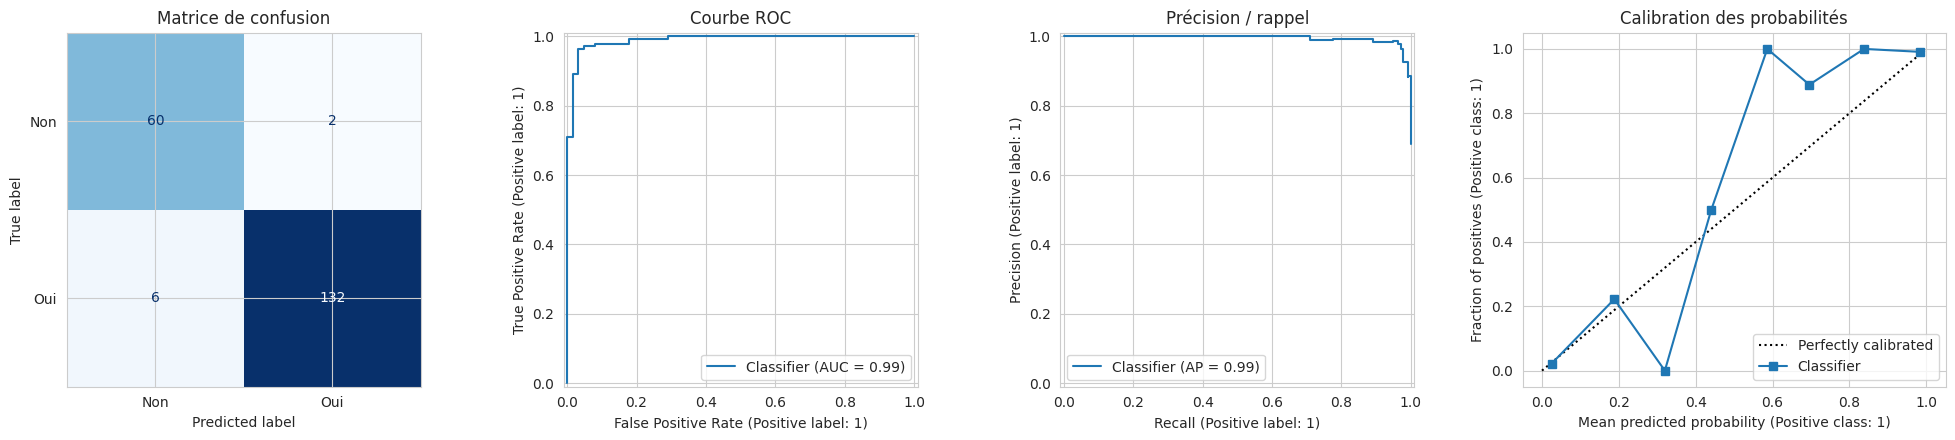

In [17]:
y_pred, y_proba = final.predict(X_te), final.predict_proba(X_te)[:, 1]
print(classification_report(y_te, y_pred, target_names=["Pas de risque (Non)", "Risque (Oui)"]))
print(f"ROC-AUC {roc_auc_score(y_te, y_proba):.4f} | PR-AUC {average_precision_score(y_te, y_proba):.4f} | Brier {brier_score_loss(y_te, y_proba):.4f}")
fig, ax = plt.subplots(1, 4, figsize=(20, 4.5))
ConfusionMatrixDisplay(confusion_matrix(y_te, y_pred), display_labels=["Non", "Oui"]).plot(ax=ax[0], colorbar=False, cmap="Blues"); ax[0].set_title("Matrice de confusion")
RocCurveDisplay.from_predictions(y_te, y_proba, ax=ax[1]); ax[1].set_title("Courbe ROC")
PrecisionRecallDisplay.from_predictions(y_te, y_proba, ax=ax[2]); ax[2].set_title("Précision / rappel")
CalibrationDisplay.from_predictions(y_te, y_proba, n_bins=8, ax=ax[3]); ax[3].set_title("Calibration des probabilités")
plt.tight_layout(); plt.show()

## 9. Interprétation : quelles variables comptent ?

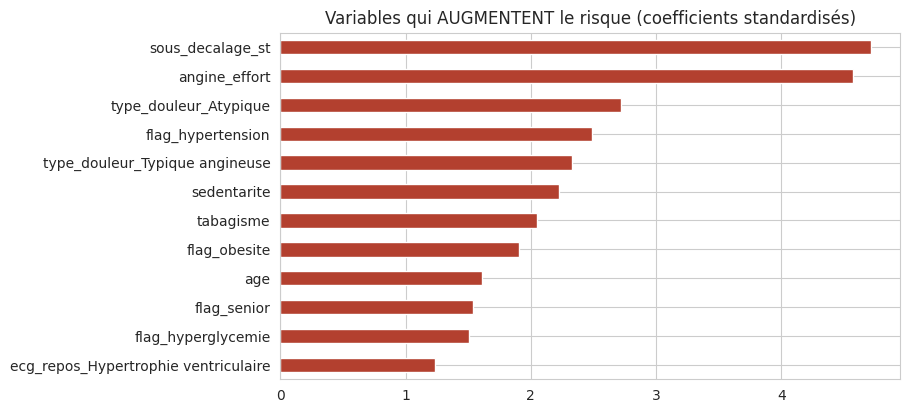

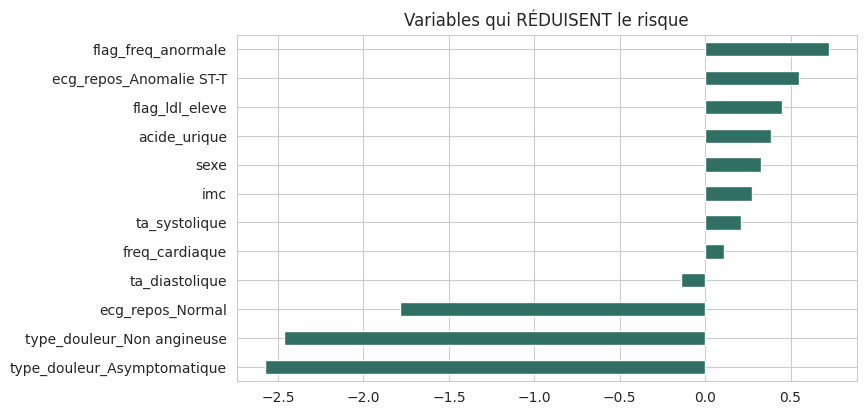

In [18]:
coef = pd.Series(final.named_steps["modele"].coef_[0], index=final.named_steps["prepro"].named_steps["transformation"].get_feature_names_out())
coef = coef.rename(lambda n: n.split("__", 1)[1]).sort_values()
coef.tail(12).plot(kind="barh", color="#B3402F", figsize=(8, 4.5), title="Variables qui AUGMENTENT le risque (coefficients standardisés)"); plt.show()
coef.head(12).plot(kind="barh", color="#2F6F64", figsize=(8, 4.5), title="Variables qui RÉDUISENT le risque"); plt.show()

## 10. Limites à garder en tête

* **Performances très élevées (ROC-AUC ≈ 0,99)** : réalistes pour un vrai jeu de données cliniques ? Non. Les taux de risque par modalité
  sont presque déterministes (ex. ~99 % de risque en cas de douleur « typique angineuse », voir section 1). Ce jeu de données semble
  **simulé à partir de règles simples** ; le modèle apprend ces règles. Ces scores ne se transposeraient pas à des patients réels.
* Seulement **1 000 patients**, âge limité à 30–80 ans : l'API signale les saisies hors de cette plage.
* Probabilités très tranchées (proches de 0 ou 1) : le site affiche « > 99 % » / « < 1 % » plutôt que 0 % / 100 %.
* Outil **pédagogique**, pas un dispositif médical.

Le modèle de production est (ré)entraîné par `train_model.py`, qui reproduit exactement cette démarche et sauvegarde les artefacts dans `heart_model/`.